# Asking one loop at a time: small-loop probing

Every localization in this project so far has worked the same way — fix a centre, shrink the loop
until the Berry phase turns over, and read the transition radius as a distance. That is expensive
(a bisection is 9 probes) and it fails in a characteristic way: the decisive probes are exactly
the ones passing closest to the degeneracy, and those are the ones the walk refuses.

This notebook is about the smaller primitive underneath it:

> **Is there a degeneracy inside *this* loop?** One loop, one bit.

At ethylene CAS(2,2) that costs about 20 seconds. It makes questions affordable that a bisection
cannot ask at all — "is the object at the state-averaged intersection?", "is it anywhere on the
mirror line?" — and it turns out to answer them differently than we expected.

**A warning that the rest of the notebook earns:** a `zero` from this primitive is only evidence
if the primitive can be shown to say `pi` when a degeneracy *is* enclosed. Section 1 establishes
that on a system where the answer is known independently; everything after it depends on that
control.

In [1]:
import glob, json, os, sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.facecolor": "white"})

COLOUR = {"pi": "tab:red", "zero": "tab:blue", "undetermined": "0.6"}
MARKER = {"pi": "o", "zero": "s", "undetermined": "x"}

def load(kind, name):
    p = os.path.join(ROOT, "results", kind, name)
    return json.load(open(p)) if os.path.exists(p) else None

def table(probes, centre_col=False):
    head = f"{'centre':>16} " if centre_col else ""
    print(head + f"{'radius':>8} {'verdict':>14} {'points':>10} {'worst ovl':>11} {'wall (s)':>9}")
    print("-" * (72 if centre_col else 56))
    for p in probes:
        runs = p.get("runs", [])
        pts = "/".join(str(r["n_points"]) for r in runs)
        ovl = min((r["min_overlap"] for r in runs), default=float("nan"))
        r0 = p["radius"][0] if isinstance(p["radius"], (list, tuple)) else p["radius"]
        lead = f"{str(tuple(p['centre'])):>16} " if centre_col else ""
        print(lead + f"{r0:>8.3g} {p['verdict']:>14} {pts:>10} {ovl:>11.3f} {p['wall_time']:>9.0f}")

## 1. Does the primitive work? A control where the answer is known

Formaldimine is the benchmark: FCI in the same basis puts the intersection at α = 132.6°, and the
`C_x` loop (centre α = 130, radius 10°) returns π in every run this project has made. At CAS(4,4)
the state-specific position was measured independently by bisection and triangulation at
**α = 128.99**, i.e. **1.01° from that loop's centre**.

So shrink concentric loops about (130, 89.9) and watch. A working primitive must report π while
the loop still encloses the degeneracy, become unreliable when it grazes it, and report 0 once it
excludes it — with the turnover at ~1°, a number known *before* the experiment.

In [2]:
ctrl = load("radius_scan", "formaldimine_cas4-4_Cx_shrink_control.json")
if ctrl:
    print(f"formaldimine CAS(4,4), concentric about {tuple(ctrl['centre'])}")
    print("independently measured distance to the state-specific degeneracy: 1.01 deg\n")
    table(ctrl["probes"])
else:
    print("run: python examples/run_radius_scan.py formaldimine --cas 4 4 "
          "--centre 130.0 89.9 --radii 10 6 4 2 1 0.5 --label Cx_shrink_control")

formaldimine CAS(4,4), concentric about (130.0, 89.9)
independently measured distance to the state-specific degeneracy: 1.01 deg

  radius        verdict     points   worst ovl  wall (s)
--------------------------------------------------------
      10             pi      16/26       0.955         6
       6             pi      16/25       0.954         8
       4             pi      16/25       0.956        11
       2             pi      15/25       0.930        28
       1   undetermined      20/26       0.910       224
     0.5           zero      13/17       0.971        12


**It works, and the turnover lands where it should.** π at radius 10, 6, 4 and 2; refused at 1 —
the loop grazing the degeneracy; 0 at 0.5. The transition sits between 0.5 and 2, bracketing the
independently measured 1.01°, and it was not tuned to do so.

Two details worth carrying forward. The cost *rises* as the loop closes in (6 s at radius 10, 224 s
at radius 1) even though the point count barely moves, because near the degeneracy the walk spends
its effort on rejected trials. And the worst adjacent overlap stays high (0.91–0.96) throughout, so
**a high overlap is not evidence that a loop is far from a degeneracy**.

In [3]:
ctrl2 = load("radius_scan", "formaldimine_cas2-2_known_CI_control.json")
if ctrl2:
    print(f"formaldimine CAS(2,2), concentric about the FCI position {tuple(ctrl2['centre'])}\n")
    table(ctrl2["probes"])
    print("\nAll zero -- and that is the right answer, not a failure of the primitive:")
    print("CAS(2,2) misplaces this intersection, and its own state-specific position was")
    print("measured near alpha = 131.7, some 3.8 deg away, outside every loop above.")

formaldimine CAS(2,2), concentric about the FCI position (132.61, 90.0)

  radius        verdict     points   worst ovl  wall (s)
--------------------------------------------------------
       4           zero      10/15       0.998         2
       2           zero      11/15       0.974         2
       1           zero      10/15       1.000         1
     0.5           zero      10/15       1.000         1
    0.25           zero      10/15       1.000         1
     0.1           zero      10/15       1.000         1

All zero -- and that is the right answer, not a failure of the primitive:
CAS(2,2) misplaces this intersection, and its own state-specific position was
measured near alpha = 131.7, some 3.8 deg away, outside every loop above.


## 2. Ethylene: shrinking the loop that reports π

`E_x` — centre (90, 110.9), radius 12° — returns π at ethylene CAS(2,2) in the active-space ladder,
under both uniform and adaptive discretization. Shrinking it concentrically asks how far away the
thing carrying that phase actually is.

In [4]:
ex = load("radius_scan", "ethylene_cas2-2_Ex_shrink.json")
gap = load("radius_scan", "ethylene_cas2-2.json")
if ex:
    print(f"ethylene CAS(2,2), concentric about E_x centre {tuple(ex['centre'])}\n")
    table(ex["probes"])
if gap:
    print(f"\nand about the state-averaged intersection {tuple(gap['centre'])}\n")
    table(gap["probes"])

ethylene CAS(2,2), concentric about E_x centre (90.0, 110.9)

  radius        verdict     points   worst ovl  wall (s)
--------------------------------------------------------
      10             pi      18/28       0.906        25
       8             pi      18/27       0.931        45
       6             pi      19/26       0.903        63
       5   undetermined      17/25       0.914        98
       4   undetermined      20/28       0.905       140
       3           zero      11/17       0.918        28

and about the state-averaged intersection (90.0, 111.0)

  radius        verdict     points   worst ovl  wall (s)
--------------------------------------------------------
       4   undetermined      20/27       0.912       130
       2           zero      11/16       0.967        21
       1           zero      10/15       0.990        18
     0.5           zero      10/15       0.999        15
    0.25           zero      10/15       1.000        11
     0.1           zero  

Read against the control, this is a clean measurement: **π at 12, 10, 8 and 6; refused at 5 and 4;
0 at 3 and below.** Same signature as formaldimine — enclosing, grazing, excluding — so whatever
carries the phase lies **4.5 ± 1.5°** from (90, 110.9).

The second table is the sharper result. Concentric loops on the **state-averaged intersection**
report 0 down to radius 0.1°, and by the control a 0 here means exclusion. So at CAS(2,2) **loop
transport is not encircling the intersection the gap scan finds.** They are different objects, and
this took a few minutes to establish where the earlier bisection took hours and left a region too
wide to discriminate.

## 3. Where is it, then? Probing the plane one loop at a time

With a cheap bit-per-loop, the plane can be swept. Three sweeps were run at radius 2 and below:
along the mirror line `tw` = 90, at the mirror pair of off-line points, and around those.

In [5]:
sweeps = {name: load("centre_probe", f"ethylene_cas2-2_{name}.json")
          for name in ("line_r2", "gaps_r2", "pair_r1", "pair_r05", "seam_along_tw")}
for name, d in sweeps.items():
    if not d:
        continue
    print(f"--- {name}  (radius {d['radius']})")
    table(d["probes"], centre_col=True)
    print()

--- line_r2  (radius 2.0)
          centre   radius        verdict     points   worst ovl  wall (s)
------------------------------------------------------------------------
   (90.0, 105.0)        2           zero      10/15       0.992        11
   (90.0, 107.0)        2           zero      11/17       0.923        27
   (90.0, 109.0)        2           zero      11/17       0.972        20
   (90.0, 113.0)        2           zero      11/15       0.976        21
   (90.0, 115.0)        2           zero      10/15       0.985        18
   (90.0, 117.0)        2           zero      10/15       0.987        19

--- gaps_r2  (radius 2.0)
          centre   radius        verdict     points   worst ovl  wall (s)
------------------------------------------------------------------------
   (90.0, 101.0)        2           zero      10/15       0.994         9
   (90.0, 121.0)        2           zero      10/15       0.988        12
   (94.0, 111.0)        2   undetermined      14/14       0.9

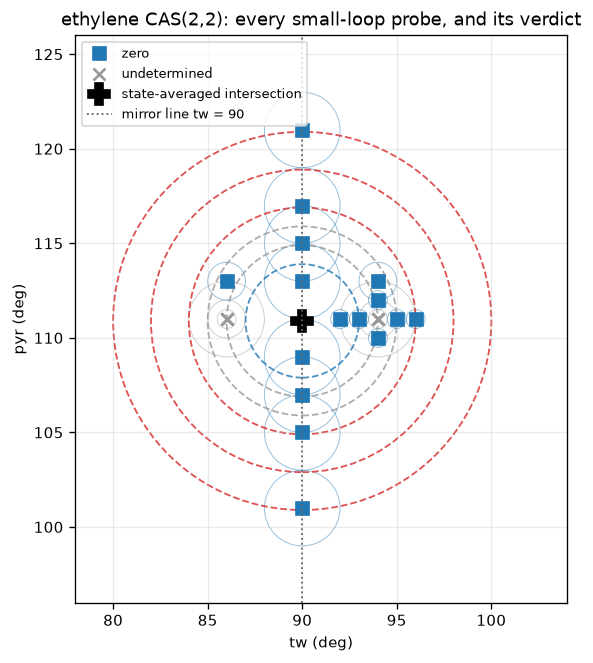

In [6]:
fig, ax = plt.subplots(figsize=(7.4, 5.6))
seen = set()
for d in sweeps.values():
    if not d:
        continue
    for p in d["probes"]:
        c = tuple(p["centre"]); v = p["verdict"]
        r0 = p["radius"][0] if isinstance(p["radius"], (list, tuple)) else p["radius"]
        ax.plot(*c, MARKER[v], color=COLOUR[v], ms=7, mew=1.6,
                label=v if v not in seen else None)
        seen.add(v)
        ax.add_patch(plt.Circle(c, r0, fill=False, edgecolor=COLOUR[v], lw=0.6, alpha=0.45))
# the E_x shrink sequence, drawn as concentric circles about its centre
if ex:
    for p in ex["probes"]:
        r0 = p["radius"][0] if isinstance(p["radius"], (list, tuple)) else p["radius"]
        ax.add_patch(plt.Circle(tuple(ex["centre"]), r0, fill=False,
                                edgecolor=COLOUR[p["verdict"]], lw=1.1, ls="--", alpha=0.8))
ax.plot(90.0, 110.9, "P", ms=13, color="k", label="state-averaged intersection")
ax.axvline(90.0, color="0.4", ls=":", lw=1.1, label="mirror line tw = 90")
ax.set_xlim(78, 104); ax.set_ylim(96, 126); ax.set_aspect("equal")
ax.set_xlabel("tw (deg)"); ax.set_ylabel("pyr (deg)")
ax.set_title("ethylene CAS(2,2): every small-loop probe, and its verdict")
ax.legend(fontsize=7.5, loc="upper left")
plt.tight_layout(); plt.show()

## 4. The count does not work out

Three facts, each measured above:

1. `E_x` and every concentric loop down to radius 6 report **π**, so an odd number of degeneracies
   lies inside them;
2. **nothing is on the mirror line**: radius-2 loops centred at `pyr` = 101, 105, 107, 109, 111,
   113, 115, 117 and 121 all report 0, covering `pyr` 99–123 without a gap;
3. `tw` and `180 − tw` are **exact mirror images**, so any degeneracy off the line has a partner at
   its reflection, and a loop centred on the line encloses both or neither.

An even count cannot produce π. Points 1–3 are therefore inconsistent, and one of them is not
measuring what it appears to.

The probes at (94, 111) and its mirror (86, 111) are where the inconsistency concentrates. They
**refuse at every radius tried — 2, 1 and 0.5** — while loops of the same size one degree away, at
(93, 111), (95, 111), (94, 110) and (94, 112), all return clean zeros. Something sits within half a
degree of those two points; the walk cannot get around it; and it never yields a π.

In [7]:
# Why the refusals: the failure messages distinguish a grazing loop from a broken solution.
for name in ("pair_r05", "pair_r1"):
    d = sweeps.get(name)
    if not d:
        continue
    for p in d["probes"]:
        if p["verdict"] != "undetermined":
            continue
        print(f"{name}  centre {tuple(p['centre'])}  radius {p['radius'][0]}")
        for r in p.get("runs", []):
            print(f"   min overlap {r['min_overlap']:.3f}, step floor hit: {r.get('hit_step_floor')}")
            for m in (r.get("messages") or [])[:2]:
                print(f"      {m[:96]}")
        print()

pair_r05  centre (94.0, 111.0)  radius 0.5
   min overlap 0.965, step floor hit: True
      the adaptive walk did not reach t = 1, so the loop was never closed and no Berry phase is define
      step floor reached: shrinking to d_min=0.001 did not restore continuity, so the problem is not d
   min overlap 0.981, step floor hit: True
      the adaptive walk did not reach t = 1, so the loop was never closed and no Berry phase is define
      step floor reached: shrinking to d_min=0.001 did not restore continuity, so the problem is not d

pair_r05  centre (86.0, 111.0)  radius 0.5
   min overlap 0.973, step floor hit: False
      endpoint |<Psi_0|Psi_N>| = 0.805 < 0.9: the loop did not return to the same state, so its sign i
   min overlap 0.989, step floor hit: False
      CASSCF did not converge at point(s) [5]
      endpoint |<Psi_0|Psi_N>| = 0.805 < 0.9: the loop did not return to the same state, so its sign i

pair_r1  centre (94.0, 111.0)  radius 1.0
   min overlap 0.977, step floor

**The failures do not look like a loop circling a conical intersection.** Around a genuine cone the
walk's adjacent overlaps collapse as the loop tightens; here they stay at **0.96–0.99** and the walk
fails anyway, in two different ways:

* at (94, 111) the walk **stalls**: shrinking the step to `d_min` = 0.001 does not restore
  continuity and the loop never closes. An arbitrarily small move in nuclear coordinates changes
  the tracked solution discontinuously;
* at (86, 111) the loop closes but **returns to a different state** — endpoint overlap 0.70–0.81 —
  and at one setting CASSCF fails to converge outright.

High overlaps everywhere, a discontinuity that survives step refinement, and a solution that does
not come back to itself: that is the signature of the **CASSCF solution branch** the continuation
is tracking ending or swapping, not of an electronic degeneracy being encircled.

If that reading is right, the π on `E_x` is reporting a feature of the *state-specific solution
manifold* rather than an S0/S1 conical intersection — which would explain why the gap scan does not
see it, why it is off the mirror line, and why no small loop around it ever returns π. It would
also be a serious caveat on the method: the detector can be triggered by something that is not a
CI.

**This is not established.** What is established is that the three facts above cannot all be about
isolated conical intersections. The next test is cheap and direct: follow the energy and the
in-active-space gap along one of the refused loops and look for the discontinuity, rather than
inferring it from the walk's complaints.

## What to take from this

* **The primitive is validated** (§1) and it is fast: a question that costs a bisection an hour
  costs it a minute.
* **A `zero` is only as good as that control** — which is why the control is first, and why it is
  run at a rung where the answer was known independently.
* At ethylene CAS(2,2), **loop transport and the gap scan are not describing the same object**, now
  shown directly rather than inferred from bracket intersections.
* **The object loop transport encircles may not be a conical intersection at all.** The counting
  argument fails, and the failure messages point at a solution discontinuity. This is the sharpest
  open question the small-loop probing has produced, and it is cheaper to settle than anything it
  replaced.